# LightGBM pool model
Global LightGBM trained on pooled data. Features: **VIX 5-day SMA**, **vix_velocity** (vix.diff(1)), **vix_momentum** (vix − vix_sma_5), **Fear & Greed change** (lag1 − lag5), month_sin, month_cos.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.multioutput import MultiOutputRegressor
import lightgbm as lgb

REPO_ROOT = Path.cwd().parent.parent
BACKEND_DIR = REPO_ROOT / "backend"
sys.path.insert(0, str(BACKEND_DIR))
sys.path.insert(0, str(Path.cwd()))

from _pool_common import (
    load_pool_data,
    build_pooled_train_stack,
    compute_metrics_averaged_over_windows,
    metrics_to_parquet,
    fetch_cnn_fear_greed_index,
    TEST_SIZE,
    FORECAST_HORIZON,
    ROLLING_STEP,
    MIN_TRAIN_STACK,
    ARTIFACTS_DIR,
    TICKERS,
)

LGB_PARAMS = dict(n_estimators=100, max_depth=4, learning_rate=0.01, random_state=42, verbosity=-1)

In [2]:
def build_feature_df(grp: pd.DataFrame):
    """Features: VIX 5-day SMA, vix_velocity (vix.diff(1)), vix_momentum (vix - vix_sma_5), Fear & Greed change (lag1 - lag5), month sin/cos. Target = next 21 returns."""
    df = grp.sort_values("timestamp").copy()
    df["close"] = df["close"].astype(float)
    df["return"] = df["close"].pct_change()
    if "vix" in df.columns:
        vix = df["vix"].astype(np.float32)
        df["vix_sma_5"] = vix.shift(1).rolling(5).mean().astype(np.float32)
        df["vix_velocity"] = vix.diff(1).astype(np.float32)
        df["vix_momentum"] = (vix - df["vix_sma_5"]).astype(np.float32)
    else:
        df["vix_sma_5"] = np.nan
        df["vix_velocity"] = np.nan
        df["vix_momentum"] = np.nan
    df["month"] = pd.to_datetime(df["timestamp"]).dt.month
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
    if "fear_greed" not in df.columns:
        df["fear_greed"] = 50.0
    else:
        df["fear_greed"] = df["fear_greed"].fillna(50.0)
    df["fear_greed_lag_1"] = df["fear_greed"].shift(1)
    df["fear_greed_lag_5"] = df["fear_greed"].shift(5)
    df["fear_greed_change"] = df["fear_greed_lag_1"] - df["fear_greed_lag_5"]
    for h in range(1, FORECAST_HORIZON + 1):
        df[f"target_{h}"] = df["return"].shift(-h)
    feature_cols = ["vix_sma_5", "vix_velocity", "vix_momentum", "month_sin", "month_cos", "fear_greed_change"]
    target_cols = [f"target_{h}" for h in range(1, FORECAST_HORIZON + 1)]
    base_cols = ["timestamp", "close", "return"] + feature_cols + target_cols
    out = df[[c for c in base_cols if c in df.columns]].copy()
    return out.dropna(), feature_cols, target_cols


def train_global_lgb(stacked: pd.DataFrame, horizon: int):
    """Train one LightGBM on pooled data (all assets, rows before 60-day test window). Returns dict for predict_lgb_global."""
    pooled = build_pooled_train_stack(stacked, TEST_SIZE, MIN_TRAIN_STACK)
    if pooled.empty:
        return None
    feat_dfs = []
    for sym in pooled["symbol"].unique():
        grp = pooled[pooled["symbol"] == sym].copy()
        try:
            feat_df, feature_cols, target_cols = build_feature_df(grp)
        except Exception:
            continue
        if len(feat_df) < MIN_TRAIN_STACK + horizon:
            continue
        feat_dfs.append(feat_df)
    if not feat_dfs:
        return None
    pooled_feat = pd.concat(feat_dfs, ignore_index=True)
    X = pooled_feat[feature_cols].values.astype(np.float32)
    y = pooled_feat[target_cols].values.astype(np.float32)
    scaler = StandardScaler()
    X_s = scaler.fit_transform(X)
    lgb_multi = MultiOutputRegressor(lgb.LGBMRegressor(**LGB_PARAMS))
    lgb_multi.fit(X_s, y)
    return {"model": lgb_multi, "scaler": scaler, "feature_cols": feature_cols}


def predict_lgb_global(context_df: pd.DataFrame, horizon: int, global_lgb: dict) -> list:
    """Predict 21 price steps using pre-trained global LightGBM."""
    if global_lgb is None:
        return []
    try:
        feat_df, feature_cols, _ = build_feature_df(context_df)
    except Exception:
        return []
    if len(feat_df) < 1:
        return []
    X = feat_df[feature_cols].values.astype(np.float32)
    X_s = global_lgb["scaler"].transform(X)
    last_row = X_s[-1:]
    pred_returns = global_lgb["model"].predict(last_row).ravel()
    p0 = float(context_df["close"].iloc[-1])
    prices = p0 * np.cumprod(np.concatenate([[1.0], 1.0 + pred_returns]))[1:]
    return [float(p) for p in prices[:horizon]]

In [3]:
# Load data and merge Fear & Greed (run this before the Random Search cell below)
stacked = load_pool_data(with_vix=True, with_volume=True)
symbol_start = pd.to_datetime(stacked["timestamp"]).min().strftime("%Y-%m-%d")
fear_greed_df = fetch_cnn_fear_greed_index(start_date=symbol_start)
if not fear_greed_df.empty:
    stacked["date"] = pd.to_datetime(stacked["timestamp"]).dt.normalize()
    fear_greed_df["date"] = pd.to_datetime(fear_greed_df["timestamp"]).dt.normalize()
    stacked = stacked.merge(fear_greed_df[["date", "fear_greed"]], on="date", how="left")
    stacked["fear_greed"] = stacked["fear_greed"].ffill().bfill()
    stacked = stacked.drop(columns=["date"])
print(stacked.groupby("symbol").size())
stacked.head(10)

symbol
AAPL     1256
AMZN     1256
GOOGL    1256
JNJ      1256
JPM      1256
MSFT     1256
NVDA     1256
SPY      1256
WMT      1256
XOM      1256
dtype: int64


,timestamp,symbol,close,volume,vix,fear_greed
0,2021-03-09,AAPL,121.089996,129525800,24.030001,43.360000
1,2021-03-10,AAPL,119.980003,111943300,22.559999,45.560000
2,2021-03-11,AAPL,121.959999,103026500,21.910000,50.480000
3,2021-03-12,AAPL,121.029999,88105100,20.690001,53.720000
4,2021-03-15,AAPL,123.989998,92403800,20.030001,56.520000
5,2021-03-16,AAPL,125.570000,115227900,19.790001,54.800000
6,2021-03-17,AAPL,124.760002,111932600,19.230000,57.866667
7,2021-03-18,AAPL,120.529999,121229700,21.580000,52.333333
8,2021-03-19,AAPL,119.989998,185549500,20.950001,50.833333
9,2021-03-22,AAPL,123.389999,111912300,18.879999,50.700000


In [4]:
# 20-iteration Random Search: Mean MAE across 21 horizons; save best params for stack notebooks (run data-load cell above first)
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import make_scorer
import json

def mean_mae_multioutput(y_true, y_pred):
    """Mean MAE over all 21 horizon columns (higher is worse; we use neg_mean_mae for scoring)."""
    return np.mean(np.abs(y_true - y_pred))

neg_mean_mae_scorer = make_scorer(mean_mae_multioutput, greater_is_better=False)

pooled = build_pooled_train_stack(stacked, TEST_SIZE, MIN_TRAIN_STACK)
feat_dfs = []
for sym in pooled["symbol"].unique():
    grp = pooled[pooled["symbol"] == sym].copy()
    try:
        feat_df, feature_cols, target_cols = build_feature_df(grp)
    except Exception:
        continue
    if len(feat_df) < MIN_TRAIN_STACK + FORECAST_HORIZON:
        continue
    feat_dfs.append(feat_df)
pooled_feat = pd.concat(feat_dfs, ignore_index=True)
pooled_feat = pooled_feat.sort_values("timestamp").reset_index(drop=True)
X_rs = pooled_feat[feature_cols].values.astype(np.float32)
y_rs = pooled_feat[target_cols].values.astype(np.float32)

pipe_lgb = Pipeline([
    ("scaler", StandardScaler()),
    ("multi", MultiOutputRegressor(lgb.LGBMRegressor(random_state=42, verbosity=-1)))
])
param_dist_lgb = {
    "multi__estimator__n_estimators": [50, 100, 150, 200],
    "multi__estimator__max_depth": [3, 4, 5, 6],
    "multi__estimator__learning_rate": [0.005, 0.01, 0.02, 0.05],
    "multi__estimator__num_leaves": [15, 31, 63],
    "multi__estimator__min_child_samples": [10, 20, 50],
    "multi__estimator__reg_alpha": [0.01, 0.1, 1.0],
    "multi__estimator__reg_lambda": [0.01, 0.1, 1.0],
}
tscv = TimeSeriesSplit(n_splits=5)
search_lgb = RandomizedSearchCV(
    pipe_lgb, param_dist_lgb, n_iter=20, cv=tscv, scoring=neg_mean_mae_scorer,
    random_state=42, n_jobs=-1, verbose=1
)
search_lgb.fit(X_rs, y_rs)

best_lgb = {k.replace("multi__estimator__", ""): v for k, v in search_lgb.best_params_.items()}
best_lgb.setdefault("random_state", 42)
best_lgb.setdefault("verbosity", -1)
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
with open(ARTIFACTS_DIR / "best_lgb_params.json", "w") as f:
    json.dump(best_lgb, f, indent=2)
LGB_PARAMS = best_lgb
print("Best Mean MAE (CV):", -search_lgb.best_score_)
print("Best LGB_PARAMS:", LGB_PARAMS)
print("Saved to", ARTIFACTS_DIR / "best_lgb_params.json")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Mean MAE (CV): 0.01312206565885655
Best LGB_PARAMS: {'reg_lambda': 0.1, 'reg_alpha': 0.1, 'num_leaves': 63, 'n_estimators': 50, 'min_child_samples': 20, 'max_depth': 3, 'learning_rate': 0.005, 'random_state': 42, 'verbosity': -1}
Saved to C:\capstone_project_unfc\model\experiments-pool\artifacts\best_lgb_params.json


In [5]:
# Train once on pooled data (all assets, only rows before 60-day test window)
global_lgb = train_global_lgb(stacked, FORECAST_HORIZON)
print("Global LightGBM trained on", len(build_pooled_train_stack(stacked, TEST_SIZE, MIN_TRAIN_STACK)), "pooled train rows.")

Global LightGBM trained on 11960 pooled train rows.


LightGBM feature importance (mean over horizons):


,feature,importance
0,vix_sma_5,101.142857
5,fear_greed_change,65.095238
1,vix_velocity,62.428571
2,vix_momentum,56.571429
3,month_sin,17.476190
4,month_cos,8.523810


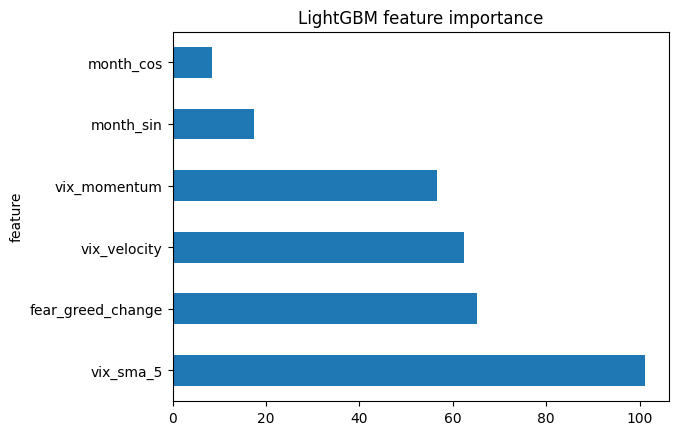

In [8]:
# Feature importance (mean across 21 horizon-specific LGBM estimators)
if global_lgb is not None:
    multi = global_lgb["model"]
    cols = global_lgb["feature_cols"]
    imp = np.array([multi.estimators_[h].feature_importances_ for h in range(len(multi.estimators_))])
    imp_mean = imp.mean(axis=0)
    fi = pd.DataFrame({"feature": cols, "importance": imp_mean}).sort_values("importance", ascending=False)
    print("LightGBM feature importance (mean over horizons):")
    display(fi)
    fi.plot(x="feature", y="importance", kind="barh", legend=False, title="LightGBM feature importance");
else:
    print("No trained model (global_lgb is None). Run the training cell above first.")

In [6]:
model_name = "lightgbm"
all_preds = []
for sym in TICKERS:
    grp = stacked[stacked["symbol"] == sym].copy()
    if grp.empty:
        continue
    grp = grp.sort_values("timestamp").reset_index(drop=True)
    prices = grp.set_index("timestamp")["close"].astype(float).dropna()
    n = len(prices)
    if n < TEST_SIZE + MIN_TRAIN_STACK:
        continue
    split_idx = n - TEST_SIZE
    test_index = prices.index[split_idx:]
    test_values = prices.values[split_idx:]
    preds = []
    window_ix = 0
    start = 0
    while start + FORECAST_HORIZON <= TEST_SIZE:
        context_cols = ["timestamp", "close", "vix"] + [c for c in ["volume", "fear_greed"] if c in grp.columns]
        context_df = grp.iloc[: split_idx + start][context_cols].copy()
        if len(context_df) < MIN_TRAIN_STACK:
            start += ROLLING_STEP
            continue
        price_list = predict_lgb_global(context_df, FORECAST_HORIZON, global_lgb)
        if not price_list or len(price_list) < FORECAST_HORIZON:
            start += ROLLING_STEP
            window_ix += 1
            continue
        for h in range(FORECAST_HORIZON):
            idx = start + h
            ts = test_index[idx]
            y_true = float(test_values[idx])
            y_pred = float(price_list[h])
            preds.append({"timestamp": ts, "y_true": y_true, "y_pred": y_pred, "window_ix": window_ix})
        window_ix += 1
        start += ROLLING_STEP
    if preds:
        pred_df = pd.DataFrame(preds)
        pred_df["symbol"] = sym
        all_preds.append(pred_df)

pred_lgb = pd.concat(all_preds, ignore_index=True) if all_preds else pd.DataFrame(
    columns=["timestamp", "y_true", "y_pred", "window_ix", "symbol"]
)
print(pred_lgb.groupby("symbol").size() if not pred_lgb.empty else "No predictions.")
pred_lgb.head()

c:\capstone_project_unfc\env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\capstone_project_unfc\env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\capstone_project_unfc\env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\capstone_project_unfc\env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\capstone_project_unfc\env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\capstone_project_

symbol
AAPL     126
AMZN     126
GOOGL    126
JNJ      126
JPM      126
MSFT     126
NVDA     126
SPY      126
WMT      126
XOM      126
dtype: int64


c:\capstone_project_unfc\env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\capstone_project_unfc\env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\capstone_project_unfc\env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\capstone_project_unfc\env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\capstone_project_unfc\env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\capstone_project_

,timestamp,y_true,y_pred,window_ix,symbol
0,2025-12-10,278.779999,277.422037,0,AAPL
1,2025-12-11,278.029999,277.710855,0,AAPL
2,2025-12-12,278.279999,277.961925,0,AAPL
3,2025-12-15,274.109985,278.224397,0,AAPL
4,2025-12-16,274.609985,278.490093,0,AAPL


In [7]:
metrics_rows = []
for sym in pred_lgb["symbol"].unique():
    sub = pred_lgb[pred_lgb["symbol"] == sym]
    m = compute_metrics_averaged_over_windows(sub)
    metrics_rows.append({"model": model_name, "symbol": sym, **m})
m_overall = compute_metrics_averaged_over_windows(pred_lgb)
metrics_rows.append({"model": model_name, "symbol": "overall", **m_overall})

metrics_df = pd.DataFrame(metrics_rows)
print(metrics_df.to_string())
metrics_to_parquet(metrics_rows, ARTIFACTS_DIR / "metrics_lightgbm_pool.parquet")
print("Saved:", ARTIFACTS_DIR / "metrics_lightgbm_pool.parquet")

       model   symbol        MAE       RMSE    MAPE_%
0   lightgbm     AAPL  11.188913  13.417393  4.262496
1   lightgbm     MSFT  28.095241  32.444213  6.555414
2   lightgbm    GOOGL  13.208618  15.282747  4.158552
3   lightgbm     AMZN  13.636857  16.059008  6.277235
4   lightgbm      JPM  13.795545  15.284031  4.405434
5   lightgbm      JNJ  10.532497  11.693755  4.589061
6   lightgbm      WMT   4.649985   5.361315  3.786685
7   lightgbm      SPY   7.679771   9.064102  1.119046
8   lightgbm      XOM   7.159911   8.439882  5.117741
9   lightgbm     NVDA   5.496066   6.851649  3.003149
10  lightgbm  overall  11.544340  15.978432  4.327481
Saved: C:\capstone_project_unfc\model\experiments-pool\artifacts\metrics_lightgbm_pool.parquet
